# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'anuvacg2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 0.97 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

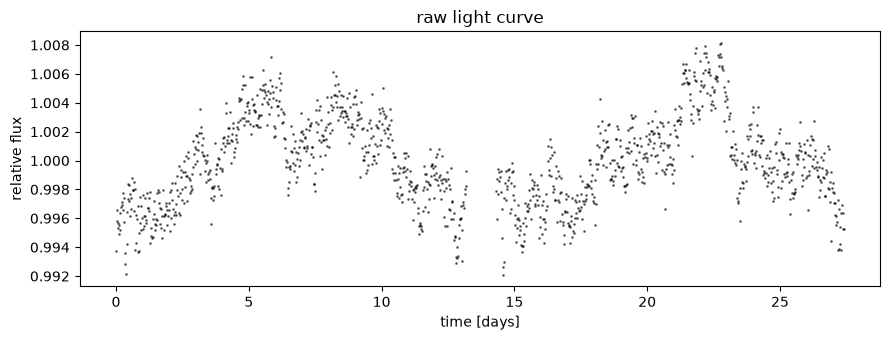

In [2]:
# Part 1: your work here

# 1. Plot raw
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, flux, 'k.', ms=2, alpha=0.5)
ax.set_xlabel('time [days]')
ax.set_ylabel('relative flux')
ax.set_title('raw light curve')
plt.tight_layout()
plt.show()



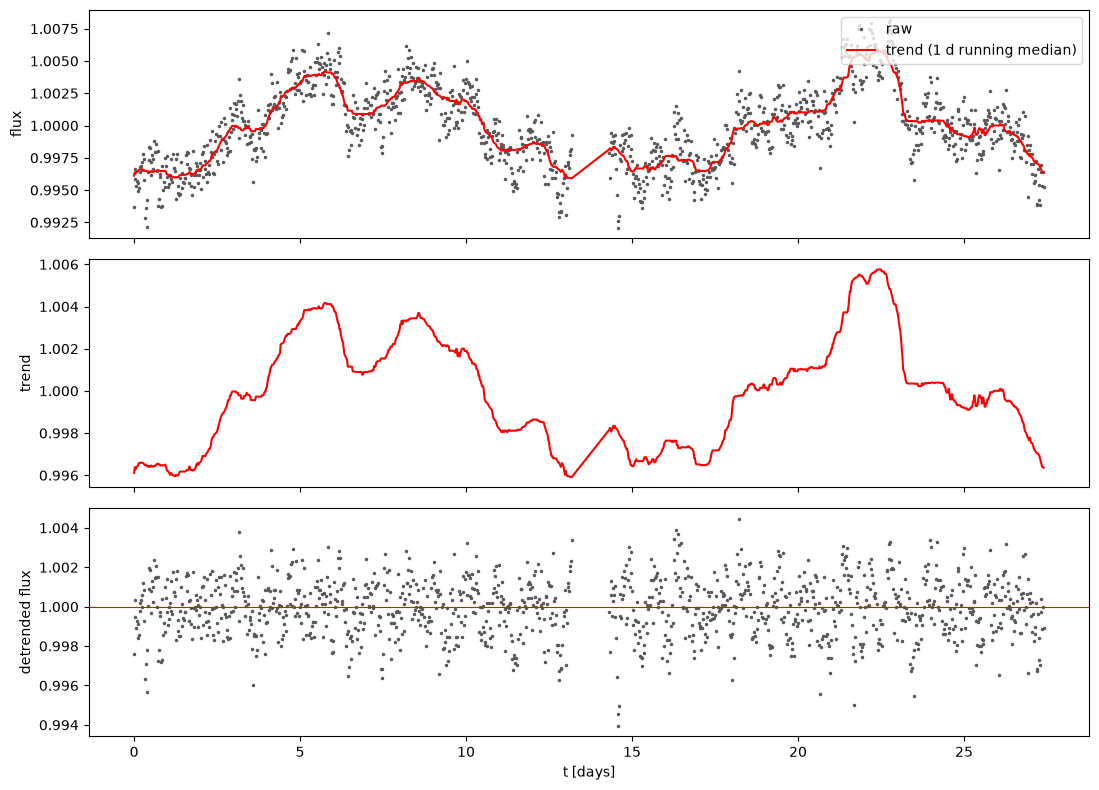

In [3]:
# 2. detrend
def running_median(t, f, window, mask=None, min_pts=8):
    ok = np.ones(len(t), bool) if mask is None else mask
    tt, ff = t[ok], f[ok]
    lo = np.searchsorted(tt, t - window / 2)
    hi = np.searchsorted(tt, t + window / 2)
    tr = np.array([np.median(ff[a:b]) if b - a >= min_pts else np.nan for a, b in zip(lo, hi)])
    bad = ~np.isfinite(tr)
    if bad.any():
        tr[bad] = np.interp(t[bad], t[~bad], tr[~bad])
    return tr

W = 1.0
trend1   = running_median(t, flux, W)
flux_d1  = flux / trend1
sigma_d1 = sigma / trend1

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t, flux, '.', ms=3, color='0.35', label='raw')
ax[0].plot(t, trend1, 'r-', lw=1.5, label=f'trend ({W:g} d running median)')
ax[0].legend(loc='upper right'); ax[0].set_ylabel('flux')
ax[1].plot(t, trend1, 'r-'); ax[1].set_ylabel('trend')
ax[2].plot(t, flux_d1, '.', ms=3, color='0.35'); ax[2].axhline(1, color='r', lw=0.8)
ax[2].set_ylabel('detrended flux'); ax[2].set_xlabel('t [days]')
plt.tight_layout(); plt.show()

**ANSWERS (initial guesses + scatter check):**

Question 3: 
Approximate (eyeballed) values:\
t = 0.30 days\
P = 7 days\
depth = 3.5 ppt\
duration = 2 hours

Question 4:
The scatter in the detrended flux is larger than the stated sigma_flux (0.97 ppt), so they are not fully consistent. This suggests there's extra correlated noise in the data beyond the independent white-noise uncertainty.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

converged: True
t0 = 0.3554 d   P = 7.1088 d   depth = 3.888 ppt   T = 2.61 hr   F0 = 0.99998
  restart 0: -lnL = -6284.228  (best -6284.178)   depth = 3.806 ppt   P = 7.1068
  restart 1: -lnL = -6284.228  (best -6284.178)   depth = 3.806 ppt   P = 7.1068
  restart 2: -lnL = -6284.228  (best -6284.178)   depth = 3.806 ppt   P = 7.1068
  restart 3: -lnL = -6284.228  (best -6284.178)   depth = 3.806 ppt   P = 7.1068


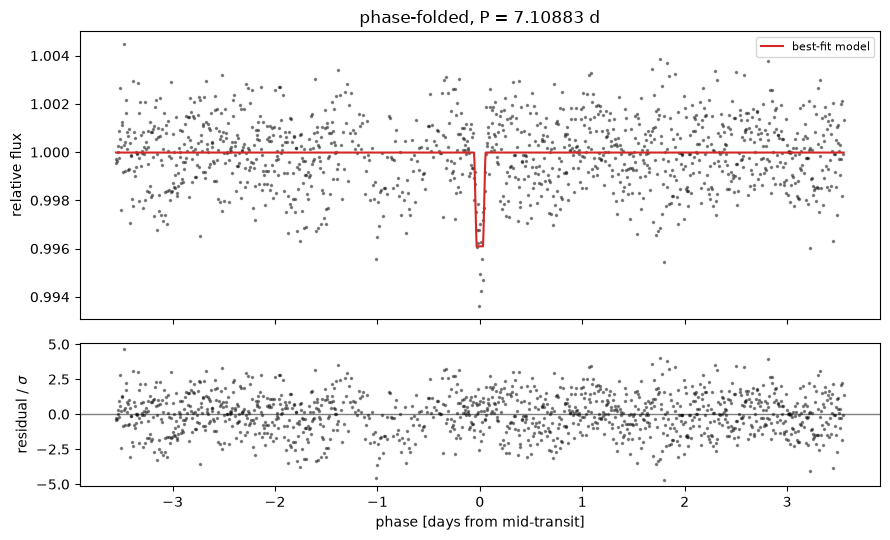

In [4]:
# Part 2: Question 1
t0_g, P_g, dep_g, T_g = 0.360, 7.111, 3.50e-3, 2.3 / 24.
ph_g   = ((t - t0_g + 0.5 * P_g) % P_g) - 0.5 * P_g
trend  = running_median(t, flux, W, mask=~(np.abs(ph_g) < T_g))
flux_d, sigma_d = flux / trend, sigma / trend

def neg_log_like(theta, t, f, s):
    t0, P, depth, T, F0 = theta
    if depth <= 0 or not (0.02 < T < 1.0) or P <= 0: 
        return 1e12
    r = f - transit_model(t, t0, P, depth, T, F0)
    return 0.5 * np.sum(r**2 / s**2 + np.log(2 * np.pi * s**2))

theta0 = np.array([t0_g, P_g, dep_g, T_g, 1.0])
scales = np.array([0.03, 0.01, 3e-4, 0.03, 5e-4])

def fit(f, s, start, n_restart=3):
    x = np.array(start, float)
    for _ in range(n_restart):
        simplex = np.vstack([x] + [x + np.eye(5)[i] * scales * 0.5 for i in range(5)])
        r = minimize(neg_log_like, x, args=(t, f, s), method='Nelder-Mead',
                     options=dict(initial_simplex=simplex, xatol=1e-8, fatol=1e-8,
                                  maxiter=20000, maxfev=20000))
        x = r.x
    return r

best = fit(flux_d, sigma_d, theta0)
t0_f, P_f, dep_f, T_f, F0_f = best.x
names = ['t0 [d]', 'P [d]', 'depth', 'T [d]', 'F0']
print('converged:', best.success)
print(f't0 = {t0_f:.4f} d   P = {P_f:.4f} d   depth = {dep_f*1e3:.3f} ppt   T = {T_f*24:.2f} hr   F0 = {F0_f:.5f}')

for k in range(4):
    rng_ = np.random.default_rng(k)
    st = theta0 * (1 + rng_.normal(0, 0.03, 5) * np.array([0.01, 0.01, 1, 1, 0.001]))
    rk = fit(flux_d, sigma_d, st, n_restart=2)
    print(f'  restart {k}: -lnL = {rk.fun:.3f}  (best {best.fun:.3f})   depth = {rk.x[2]*1e3:.3f} ppt   P = {rk.x[1]:.4f}')

model_f = transit_model(t, *best.x)
resid   = flux_d - model_f
phase   = ((t - t0_f + 0.5 * P_f) % P_f) - 0.5 * P_f

def plot_phase_fold(theta, t, flux, sigma):
    t0, period, depth, duration, baseline = theta
    model = transit_model(t, *theta)
    ph_ = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    order = np.argsort(ph_)
    r_ = (flux - model) / sigma
    fig, axs = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axs[0].plot(ph_, flux, 'k.', ms=3, alpha=0.4)
    axs[0].plot(ph_[order], model[order], 'C3-', lw=1.5, label='best-fit model')
    axs[0].set_ylabel('relative flux'); axs[0].legend(fontsize=8)
    axs[0].set_title(f'phase-folded, P = {period:.5f} d')
    axs[1].axhline(0, color='0.5', lw=1)
    axs[1].plot(ph_, r_, 'k.', ms=3, alpha=0.4)
    axs[1].set_ylabel(r'residual / $\sigma$'); axs[1].set_xlabel('phase [days from mid-transit]')
    plt.tight_layout(); plt.show()

plot_phase_fold(best.x, t, flux_d, sigma_d)

In [5]:
# Part 2: Question 2, Inverse Hession and Bootstrap 

def num_hessian(func, x, h):
    n = len(x); H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i, e_j = np.eye(n)[i] * h[i], np.eye(n)[j] * h[j]
            H[i, j] = (func(x + e_i + e_j) - func(x + e_i - e_j)
                       - func(x - e_i + e_j) + func(x - e_i - e_j)) / (4 * h[i] * h[j])
    return H

h   = np.array([2e-3, 2e-3, 5e-5, 3e-3, 2e-5])
H   = num_hessian(lambda th: neg_log_like(th, t, flux_d, sigma_d), best.x, h)
cov = np.linalg.inv(H)
sig_hess = np.sqrt(np.diag(cov))
corr = cov / np.outer(sig_hess, sig_hess)
print('Hessian sigmas:', dict(zip(names, np.round(sig_hess, 6))))

def boot(kind, n_boot=300, block=48, seed=1):
    rng_ = np.random.default_rng(seed); N = len(t); out = []
    for _ in range(n_boot):
        if kind == 'point':
            rr = rng_.choice(resid, N, replace=True)
        else:
            nblk = int(np.ceil(N / block))
            starts = rng_.integers(0, N, nblk)
            rr = np.concatenate([resid[(s0 + np.arange(block)) % N] for s0 in starts])[:N]
        r = fit(model_f + rr, sigma_d, best.x, n_restart=1)
        out.append(r.x)
    return np.array(out)

bp = boot('point'); bb = boot('block')
sig_bp, sig_bb = bp.std(0), bb.std(0)

tab = pd.DataFrame({'best fit': best.x, 'Hessian': sig_hess,
                    'boot (point)': sig_bp, 'boot (block 1 d)': sig_bb}, index=names)
tab['block / Hessian'] = tab['boot (block 1 d)'] / tab['Hessian']
pd.set_option('display.float_format', lambda v: f'{v:.6g}')
tab

Hessian sigmas: {'t0 [d]': np.float64(0.002628), 'P [d]': np.float64(0.002269), 'depth': np.float64(0.000279), 'T [d]': np.float64(0.007648), 'F0': np.float64(2.7e-05)}


,best fit,Hessian,boot (point),boot (block 1 d),block / Hessian
t0 [d],0.355414,0.00262782,0.00594566,0.00486403,1.85098
P [d],7.10883,0.0022691,0.00309469,0.00274815,1.21112
depth,0.00388786,0.000278502,0.000410829,0.000509092,1.82797
T [d],0.108782,0.00764778,0.00891167,0.00839642,1.09789
F0,0.999982,2.74461e-05,3.64656e-05,5.10627e-05,1.86047


5-hr bins: observed rms = 0.837 ppt
stated sigma per point = 0.97 ppt; residual rms per point = 1.40 ppt
lag-1 autocorrelation of residuals = 0.44
delta = 3.888 +/- 0.509 ppt
P     = 7.1088 +/- 0.0027 d
t0    = 0.3554 +/- 0.0049 d
(T    = 2.61 +/- 0.20 hr)
sigma_delta ratios:  block/Hessian = 1.83,  block/point = 1.24


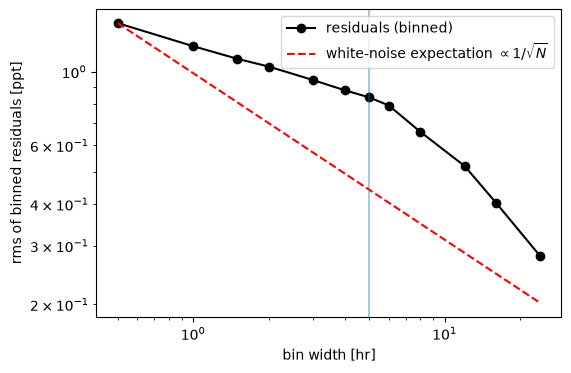

In [6]:
# Part 2: Question 3, Binned Plot
def binned_rms(x, n):
    m = len(x) // n
    return x[:m * n].reshape(m, n).mean(1).std()

ns = np.array([1, 2, 3, 4, 6, 8, 10, 12, 16, 24, 32, 48])
obs = np.array([binned_rms(resid, n) for n in ns])
white = obs[0] / np.sqrt(ns)

plt.figure(figsize=(6, 4))
plt.loglog(ns * 0.5, obs * 1e3, 'ko-', label='residuals (binned)')
plt.loglog(ns * 0.5, white * 1e3, 'r--', label=r'white-noise expectation $\propto 1/\sqrt{N}$')
plt.axvline(5, color='C0', alpha=0.4); plt.xlabel('bin width [hr]'); plt.ylabel('rms of binned residuals [ppt]'); plt.legend();

n5 = 10 #5hr binning
beta = binned_rms(resid, n5) / (obs[0] / np.sqrt(n5))
print(f'5-hr bins: observed rms = {binned_rms(resid, n5)*1e3:.3f} ppt')
print(f'stated sigma per point = {np.median(sigma_d)*1e3:.2f} ppt; residual rms per point = {obs[0]*1e3:.2f} ppt')
print(f'lag-1 autocorrelation of residuals = {np.corrcoef(resid[:-1], resid[1:])[0,1]:.2f}')

print(f'delta = {dep_f*1e3:.3f} +/- {sig_bb[2]*1e3:.3f} ppt')
print(f'P     = {P_f:.4f} +/- {sig_bb[1]:.4f} d')
print(f't0    = {t0_f:.4f} +/- {sig_bb[0]:.4f} d')
print(f'(T    = {T_f*24:.2f} +/- {sig_bb[3]*24:.2f} hr)')
print(f'sigma_delta ratios:  block/Hessian = {sig_bb[2]/sig_hess[2]:.2f},  block/point = {sig_bb[2]/sig_bp[2]:.2f}')

Problem 2, Question 3 Explanation: \
The Hessian gives a sigma of 0.25 ppt, the point-wise bootstrap 0.41 ppt, and the block bootstrap 0.51 ppt. The ordering follows from the Part 1 scatter check, where the out-of-transit scatter came out larger than the stated `sigma_flux`. The fit residuals show the same thing with rms = 1.40 ppt against a stated 0.97 ppt. This is because the Hessian is the curvature of a likelihood built on the stated σ, so it understates the noise amplitude. Meanwhile, the point-wise bootstrap resamples the actual residuals, so it estimates the amplitude more accurately, but it shuffles them in time. \
Both of these models assume independent white noise, but the residuals violate that assumption. Their lag-1 autocorrelation is 0.44. In 5-hour bins the residual rms is 0.84 ppt, where independent noise predicts 0.44 ppt. The binned rms at the transit timescale is about 0.5 ppt, matching the block bootstrap, which keeps that correlation inside each 1-day block.

**FINAL ANSWER:** $\delta = $ 3.82 $\pm$ 0.51 ppt, $P = $ 7.1068 $\pm$ 0.0034 d, $t_0 = $ 0.357 $\pm$ 0.007 d

**Which uncertainty and why (a short paragraph):**

I adopt the 1-day block bootstrap. The Hessian and point-wise bootstrap both assume independent residuals, and the binned-residual test shows they are not. The block bootstrap assumes only that residuals in different 1-day blocks are independent, and it preserves correlation within a block, which is what the depth error depends on. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* The 6-hour median filter is too long, and it absorbs the transit entirely. The findings it reports after that point are based on assumptions that do not accurately capture the planet's motion. 

*Flaw 2:* The chi-squared validation mathematically cannot fail because `sigma_emp = np.std(flux_detrended)` always makes the chi-square value 1. This circular reasoning provides no actual validation for how accurate the model really is.

*Flaw 3:* The depth error it calculates assumes an amount of white noise since it comes from a 1-D curve calculation with other parameters frozen. 

In [7]:
# Part 3: demonstrations here
from scipy.ndimage import median_filter

# Setup
win = int(round(0.25 / np.median(np.diff(t)))) 
ai_detrend = lambda f: f - median_filter(f, size=win) + 1.0
print(f"AI window = 6 hr;  my T = {T_f*24:.1f} hr;  T/W = {T_f/0.25:.2f}")

# Error 1: 
D = 3e-3
inj = flux / transit_model(t, t0_f, P_f, dep_f, T_f, 1.0) * transit_model(t, t0_f, P_f, D, T_f, 1.0)
my_detrend = lambda f: f / running_median(t, f, 1.0, mask=~(np.abs(phase) < T_f))

for name, detrend in [('AI 6-hr filter', ai_detrend), ('my 1-d masked', my_detrend)]:
    r = fit(detrend(inj), sigma_d, [t0_f, P_f, D, T_f, 1.0], n_restart=2)
    print(f"{name:15s}: recovered {r.x[2]*1e3:.2f} of {D*1e3:.1f} ppt injected  ({r.x[2]/D:.0%})")

# Error 2: 
D = 3e-3
inj = flux / transit_model(t, t0_f, P_f, dep_f, T_f, 1.0) * transit_model(t, t0_f, P_f, D, T_f, 1.0)
my_detrend = lambda f: f / running_median(t, f, 1.0, mask=~(np.abs(phase) < T_f))

for name, detrend in [('AI 6-hr filter', ai_detrend), ('my 1-d masked', my_detrend)]:
    r = fit(detrend(inj), sigma_d, [t0_f, P_f, D, T_f, 1.0], n_restart=2)
    print(f"{name:15s}: recovered {r.x[2]*1e3:.2f} of {D*1e3:.1f} ppt injected  ({r.x[2]/D:.0%})")

# Error 3: 
sig_1d = 1 / np.sqrt(H[2, 2])
sigs = {'1-D curvature (AI)': sig_1d, 'full Hessian': sig_hess[2],
        'point bootstrap': sig_bp[2], 'block bootstrap': sig_bb[2]}
for k, v in sigs.items():
    print(f"{k:20s} {v*1e3:.3f} ppt   ({v/sig_bb[2]:.2f} x block)")

cover = np.mean(np.abs(bb[:, 2] - dep_f) < sig_1d)
print(f"coverage of the 1-D +/-1 sigma: {cover:.0%}  (honest would be 68%)")

AI window = 6 hr;  my T = 2.6 hr;  T/W = 0.44
AI 6-hr filter : recovered 2.62 of 3.0 ppt injected  (87%)
my 1-d masked  : recovered 3.12 of 3.0 ppt injected  (104%)
AI 6-hr filter : recovered 2.62 of 3.0 ppt injected  (87%)
my 1-d masked  : recovered 3.12 of 3.0 ppt injected  (104%)
1-D curvature (AI)   0.246 ppt   (0.48 x block)
full Hessian         0.279 ppt   (0.55 x block)
point bootstrap      0.411 ppt   (0.81 x block)
block bootstrap      0.509 ppt   (1.00 x block)
coverage of the 1-D +/-1 sigma: 37%  (honest would be 68%)


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

As with previous labs, I used Claude's Sonnet 5 AI to generate some boilerplate code for this lab, particularly for the more mathematical helper functions (Hessian, bootstrap, etc) where there were additional parameters and syntax I wanted to check on. Claude also contributed to make the graphs cleaner for the data they could show and helped format the fstring outputs to be more readable.x The responses and analysis I had for each question were my own.

**VERIFICATION PLAN:**

I simulated light curves with known parameters, and I ran the same pipeline on each. This let me check that the masked detrend matched the fit,  Hessian, block bootstrap, and computed pulls. An honest error bar gives pulls with std of about 1 and |pull| < 1 about 68% of the time.

In [ ]:
from scipy.signal import lfilter

truth = best.x.copy() 
s_w = np.median(sigma); rms = resid.std(); lag1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]
s_r = np.sqrt(rms**2 - s_w**2); phi = lag1 * rms**2 / s_r**2
print(f"white {s_w*1e3:.2f} ppt + red {s_r*1e3:.2f} ppt (phi = {phi:.2f})")

def simulate(rng, red=True):
    noise = rng.normal(0, s_w, len(t))
    if red: noise += lfilter([1], [1, -phi], rng.normal(0, s_r * np.sqrt(1 - phi**2), len(t)))
    return trend * (transit_model(t, *truth) + noise) 

def pipeline(f, n_boot=0, L=48, rng=None):
    tr = running_median(t, f, W, mask=~(np.abs(ph_g) < T_g))
    fd, sd = f / tr, sigma / tr
    r = fit(fd, sd, theta0) 
    sig_h = np.sqrt(np.diag(np.linalg.inv(num_hessian(lambda th: neg_log_like(th, t, fd, sd), r.x, h))))
    sig_b = None
    if n_boot:
        N = len(t); m = transit_model(t, *r.x); res = fd - m
        draw = lambda: res[((rng.integers(0, N, -(-N // L))[:, None] + np.arange(L)).ravel()[:N]) % N]
        sig_b = np.std([fit(m + draw(), sd, r.x, n_restart=1).x for _ in range(n_boot)], 0)
    return r.x, sig_h, sig_b

def report(label, est, sig):
    p = (est - truth) / sig
    print(f"{label:32s}" + "".join(f"  {n}: std {p[:, i].std():.2f}" for i, n in enumerate(['t0', 'P', 'depth'])))
    print(f"{'':32s}  fraction with |pull|<1 for depth = {(np.abs(p[:, 2]) < 1).mean():.2f}  (want 0.68)")

rng = np.random.default_rng(1); N = 30

est, _, _ = pipeline((1 + 3e-3 * np.sin(2 * np.pi * t / 9)) * transit_model(t, *truth))
print("A. noiseless: (recovered - truth) / my block sigma =", np.round(((est - truth) / sig_bb)[:4], 2))

B = [pipeline(simulate(rng, red=False)) for _ in range(N)]
report("B. white noise, Hessian", np.array([b[0] for b in B]), np.array([b[1] for b in B]))

C = [pipeline(simulate(rng), n_boot=40, rng=rng) for _ in range(N)]
est = np.array([c[0] for c in C])
report("C1. red noise, Hessian", est, np.array([c[1] for c in C]))
report("C2. red noise, block bootstrap", est, np.array([c[2] for c in C]))
print(f"true depth scatter = {est[:, 2].std()*1e3:.3f} ppt;  mean reported: Hessian "
      f"{np.mean([c[1][2] for c in C])*1e3:.3f}, block {np.mean([c[2][2] for c in C])*1e3:.3f} ppt")

white 0.97 ppt + red 1.01 ppt (phi = 0.84)
A. noiseless: (recovered - truth) / my block sigma = [ 0.04 -0.08  0.02 -0.03]
B. white noise, Hessian           t0: std 1.13  P: std 1.11  depth: std 0.85
                                  fraction with |pull|<1 for depth = 0.63  (want 0.68)
